# 1. IMPORTS

In [1]:
!pip install tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# 2. DATA PREPROCESSING

In [3]:
print("Loading and Preprocessing Data...")

# Load datasets (Assumes files are in the same directory/Colab environment)
normal_df = pd.read_csv("ptbdb_normal.csv", header=None)
abnormal_df = pd.read_csv("ptbdb_abnormal.csv", header=None)

# The last column is the label (0 for normal, 1 for abnormal). 
# We drop it to isolate the features.
normal_data = normal_df.iloc[:, :-1].values
abnormal_data = abnormal_df.iloc[:, :-1].values

# Split normal data into Train (80%) and Test (20%)
X_normal_train, X_normal_test = train_test_split(normal_data, test_size=0.2, random_state=42)

# Scale the data to be between 0 and 1 (important for Autoencoders using Sigmoid)
scaler = MinMaxScaler()
X_normal_train_scaled = scaler.fit_transform(X_normal_train)
X_normal_test_scaled = scaler.transform(X_normal_test)
X_abnormal_scaled = scaler.transform(abnormal_data)

print(f"Normal Train shape: {X_normal_train_scaled.shape}")
print(f"Normal Test shape: {X_normal_test_scaled.shape}")
print(f"Abnormal Test shape: {X_abnormal_scaled.shape}")


Loading and Preprocessing Data...
Normal Train shape: (3236, 187)
Normal Test shape: (810, 187)
Abnormal Test shape: (10506, 187)


# 3. MODEL DESIGN & REGULARIZATION

In [4]:
input_dim = X_normal_train_scaled.shape[1]

def build_autoencoder(input_dim, learning_rate=0.001):
    input_layer = layers.Input(shape=(input_dim,))
    
    # Encoder (L2 regularization + Dropout to prevent overfitting)
    encoded = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(input_layer)
    encoded = layers.Dropout(0.2)(encoded)
    encoded = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(encoded)
    encoded = layers.Dense(16, activation='relu')(encoded)  # Bottleneck layer
    
    # Decoder (L2 regularization, no Dropout to preserve reconstruction quality)
    decoded = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(encoded)
    decoded = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(decoded)
    decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)  # Sigmoid because data is scaled 0-1
    
    autoencoder = models.Model(inputs=input_layer, outputs=decoded)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    autoencoder.compile(optimizer=optimizer, loss='mae')  # MAE for reconstruction
    
    return autoencoder

autoencoder = build_autoencoder(input_dim=input_dim, learning_rate=0.001)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 187)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 187)            │        12,155 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,451 (115.04 KB)

 Trainable params: 29,451 (115.04 KB)

 Non-trainable params: 0 (0.00 B)

# 4. TRAINING & TUNING

In [5]:
# Early stopping to halt training when validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

print("Training Autoencoder...")
# Note: Input and Target are both X_normal_train_scaled
history = autoencoder.fit(
    X_normal_train_scaled, X_normal_train_scaled,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Training Autoencoder...
Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.3217 - val_loss: 0.2182
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1749 - val_loss: 0.1415
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1436 - val_loss: 0.1286
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1339 - val_loss: 0.1189
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1209 - val_loss: 0.1010
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0960 - val_loss: 0.0816
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0811 - val_loss: 0.0734
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0744 - val_loss: 0.0688
Epoch 9/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0712 - val_loss: 0.0672
Epoch 10/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0694 - val_loss: 0.0655
Epoch 11/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0678 - val_loss: 0.0650
Epoch 12/200
23/23 ━━━━━━━━━━━━━━━━━━━

# 5. EVALUATION & THRESHOLD CALCULATION

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step

--- Model Evaluation Metrics ---
Accuracy:  0.8598
Precision: 0.9492
Recall:    0.8969
F1-Score:  0.9223


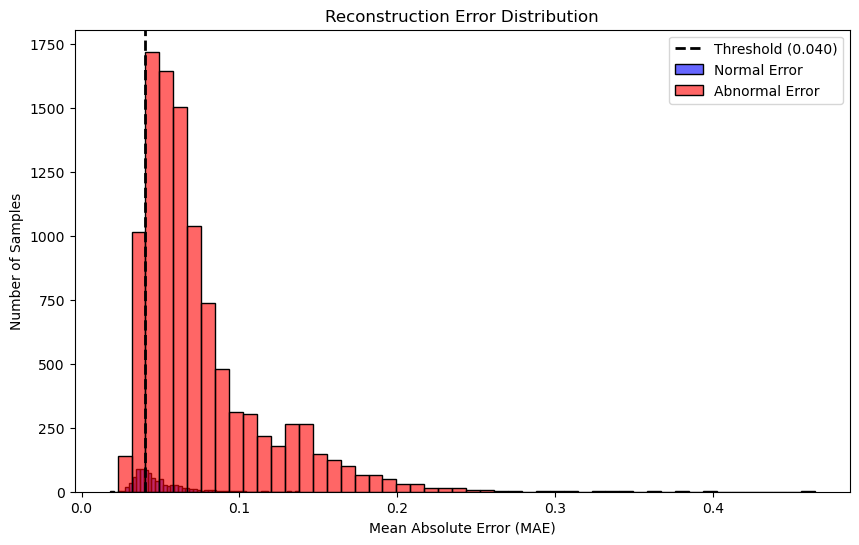

In [6]:
# Calculate reconstruction error on normal training data
train_predictions = autoencoder.predict(X_normal_train_scaled)
train_mae_loss = np.mean(np.abs(train_predictions - X_normal_train_scaled), axis=1)

# Set an anomaly threshold: Mean + 2 Standard Deviations
# threshold = np.mean(train_mae_loss) + 2 * np.std(train_mae_loss)
# print(f"\nCalculated Anomaly Threshold: {threshold:.4f}")
threshold = 0.04

# Reconstruct Normal Test Data
normal_test_predictions = autoencoder.predict(X_normal_test_scaled)
normal_test_loss = np.mean(np.abs(normal_test_predictions - X_normal_test_scaled), axis=1)

# Reconstruct Abnormal Test Data
abnormal_test_predictions = autoencoder.predict(X_abnormal_scaled)
abnormal_test_loss = np.mean(np.abs(abnormal_test_predictions - X_abnormal_scaled), axis=1)

# Prepare combined test data for final metric evaluation
# True labels: 0 for Normal, 1 for Abnormal
y_true = np.concatenate([np.zeros(len(normal_test_loss)), np.ones(len(abnormal_test_loss))])
y_scores = np.concatenate([normal_test_loss, abnormal_test_loss])

# Predict: 1 if loss > threshold else 0
y_pred = (y_scores > threshold).astype(int)

# Calculate Evaluation Metrics
print("\n--- Model Evaluation Metrics ---")
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")

# Plotting the Reconstruction Loss Distributions
plt.figure(figsize=(10, 6))
sns.histplot(normal_test_loss, bins=50, color='blue', alpha=0.6, label='Normal Error')
sns.histplot(abnormal_test_loss, bins=50, color='red', alpha=0.6, label='Abnormal Error')
plt.axvline(threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold ({threshold:.3f})')
plt.title("Reconstruction Error Distribution")
plt.xlabel("Mean Absolute Error (MAE)")
plt.ylabel("Number of Samples")
plt.legend()
plt.show()

# 6. MODEL SAVING & LOADING

In [7]:
# Save the model architecture and weights
model_path = "ecg_anomaly_autoencoder.keras"
autoencoder.save(model_path)
print(f"\nModel successfully saved to {model_path}")

# To verify loading works:
loaded_model = tf.keras.models.load_model(model_path)
print("Model loaded successfully.")


Model successfully saved to ecg_anomaly_autoencoder.keras
Model loaded successfully.
